### COMPARATIVE ANALYSIS BETWEEN KMEANS AND DBSCAN FOR BOTH PCA AND t-SNE

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
dataset = pd.read_csv('Mall_Customers.csv')

In [4]:
!pip install umap-learn

   ---------------------------------------- 0.0/91.8 kB ? eta -:--:--
   ----------------- ---------------------- 41.0/91.8 kB ? eta -:--:--
   ---------------------------------------- 91.8/91.8 kB 523.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/73.5 kB ? eta -:--:--
   ---------------------------------------  71.7/73.5 kB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 73.5/73.5 kB 269.2 kB/s eta 0:00:00


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

### STANDARDIZE DATA

In [ ]:
df = dataset.drop(['CustomerID'], axis=1)

df = pd.get_dummies(df, columns=['Gender'], dtype=int)
scaler = StandardScaler()
X_scale = scaler.fit(df)
X_scaled = X_scale.transform(df)

print(df.head())
print(X_scaled[:5])

   Age  Annual Income (k$)  Spending Score (1-100)  Gender_Female  Gender_Male
0   19                  15                      39              0            1
1   21                  15                      81              0            1
2   20                  16                       6              1            0
3   23                  16                      77              1            0
4   31                  17                      40              1            0
[[-1.42456879 -1.73899919 -0.43480148 -1.12815215  1.12815215]
 [-1.28103541 -1.73899919  1.19570407 -1.12815215  1.12815215]
 [-1.3528021  -1.70082976 -1.71591298  0.88640526 -0.88640526]
 [-1.13750203 -1.70082976  1.04041783  0.88640526 -0.88640526]
 [-0.56336851 -1.66266033 -0.39597992  0.88640526 -0.88640526]]


#### APPLYING PCA AND t-SNE WITH UMAP TO VISUALIZE AND EXPLORE  DATA

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

c:\Users\Tammy\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


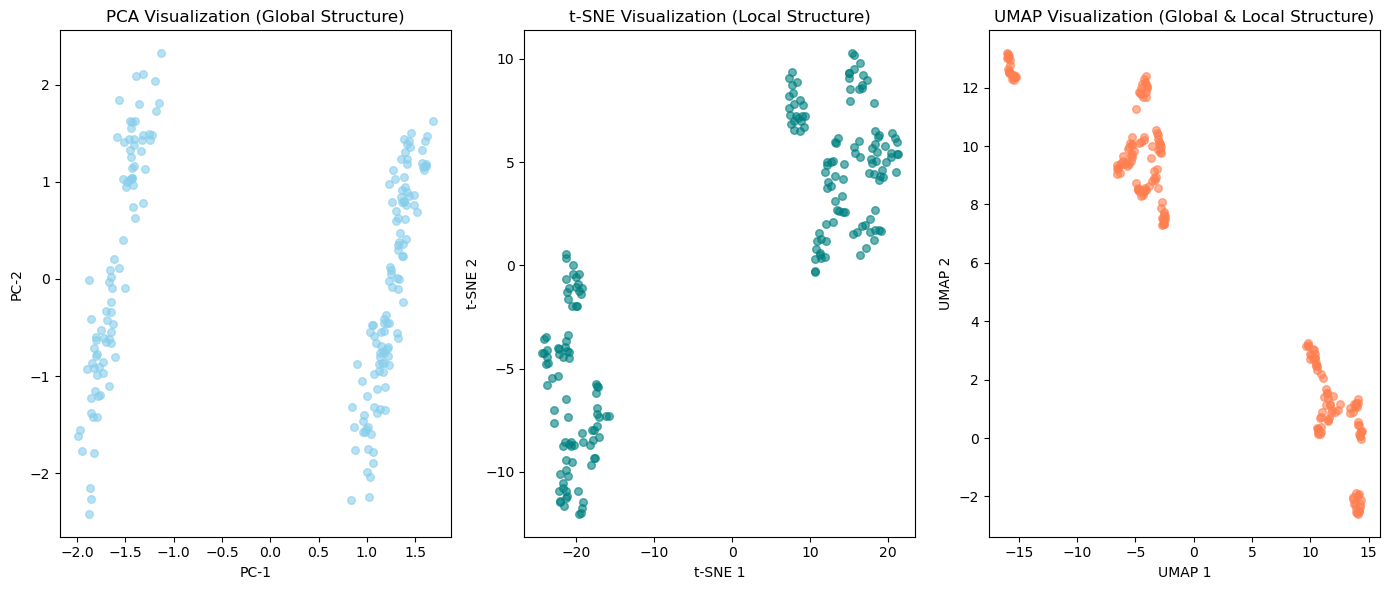

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

axes[0].scatter(X_pca[:,0], X_pca[:,1], alpha=0.6, s=30, c='skyblue')
axes[0].set_title('PCA Visualization (Global Structure)')
axes[0].set_xlabel('PC-1')
axes[0].set_ylabel('PC-2')

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6, s=30, c='teal')
axes[1].set_title('t-SNE Visualization (Local Structure)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

axes[2].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.6, s=30, c='coral')
axes[2].set_title('UMAP Visualization (Global & Local Structure)')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')


plt.tight_layout()
plt.show()

### Kmeans vs DBSAN visualization for PCA, t-SNE and UMAP

c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


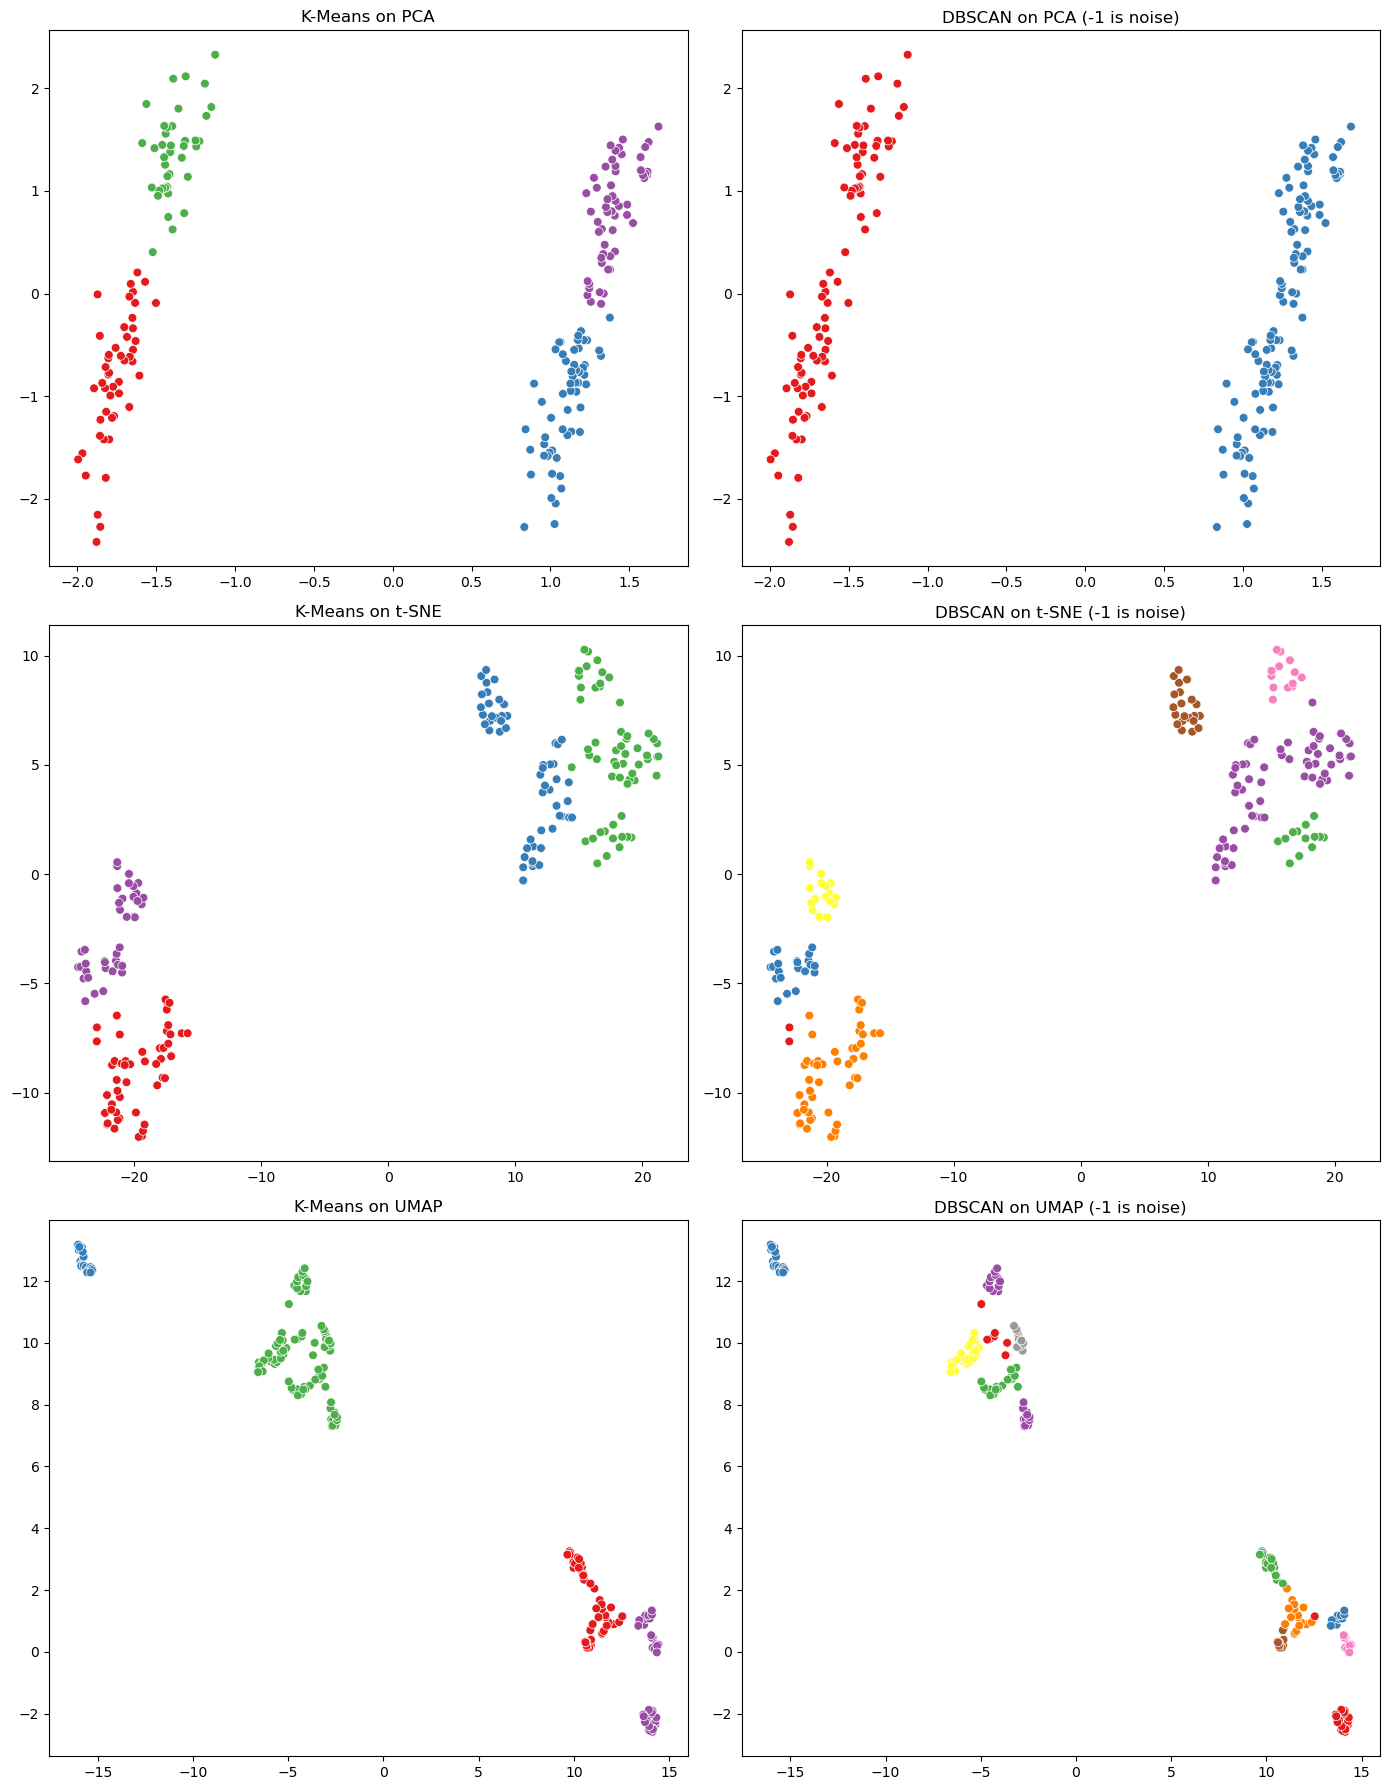

In [12]:
k = 4
# --- PCA Models ---
kmeans_pca = KMeans(n_clusters=k, init='k-means++', random_state=42).fit_predict(X_pca)
dbscan_pca = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_pca)

# --- t-SNE Models ---
kmeans_tsne = KMeans(n_clusters=k, init='k-means++', random_state=42).fit_predict(X_tsne)
dbscan_tsne = DBSCAN(eps=1.5, min_samples=5).fit_predict(X_tsne) # Note: t-SNE scale often requires larger eps for DBSCAN

# --- UMAP Models ---
kmeans_umap = KMeans(n_clusters=k, init='k-means++', random_state=42).fit_predict(X_umap)
dbscan_umap = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_umap)


# --- 4. VISUAL COMPARISON GRID (3 Rows x 2 Columns) ---
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# Row 1: PCA
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_pca, palette='Set1', ax=axes[0, 0], s=40, legend=False)
axes[0, 0].set_title('K-Means on PCA')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_pca, palette='Set1', ax=axes[0, 1], s=40, legend=False)
axes[0, 1].set_title('DBSCAN on PCA (-1 is noise)')

# Row 2: t-SNE
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans_tsne, palette='Set1', ax=axes[1, 0], s=40, legend=False)
axes[1, 0].set_title('K-Means on t-SNE')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=dbscan_tsne, palette='Set1', ax=axes[1, 1], s=40, legend=False)
axes[1, 1].set_title('DBSCAN on t-SNE (-1 is noise)')

# Row 3: UMAP
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=kmeans_umap, palette='Set1', ax=axes[2, 0], s=40, legend=False)
axes[2, 0].set_title('K-Means on UMAP')

sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=dbscan_umap, palette='Set1', ax=axes[2, 1], s=40, legend=False)
axes[2, 1].set_title('DBSCAN on UMAP (-1 is noise)')

plt.tight_layout()
plt.show()

### DROPPING THE GENDER COLUMN FROM THE DATASET TO SEE IT'S EFFECT

In [14]:
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
df_1 = dataset.drop(['CustomerID', 'Gender'], axis=1)

scaler = StandardScaler()
scale = scaler.fit(df_1)
scaled = scale.transform(df_1)

print(df_1.head())
print(scaled[:5])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(scaled)

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(scaled)

   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                      81
2   20                  16                       6
3   23                  16                      77
4   31                  17                      40
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


c:\Users\Tammy\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


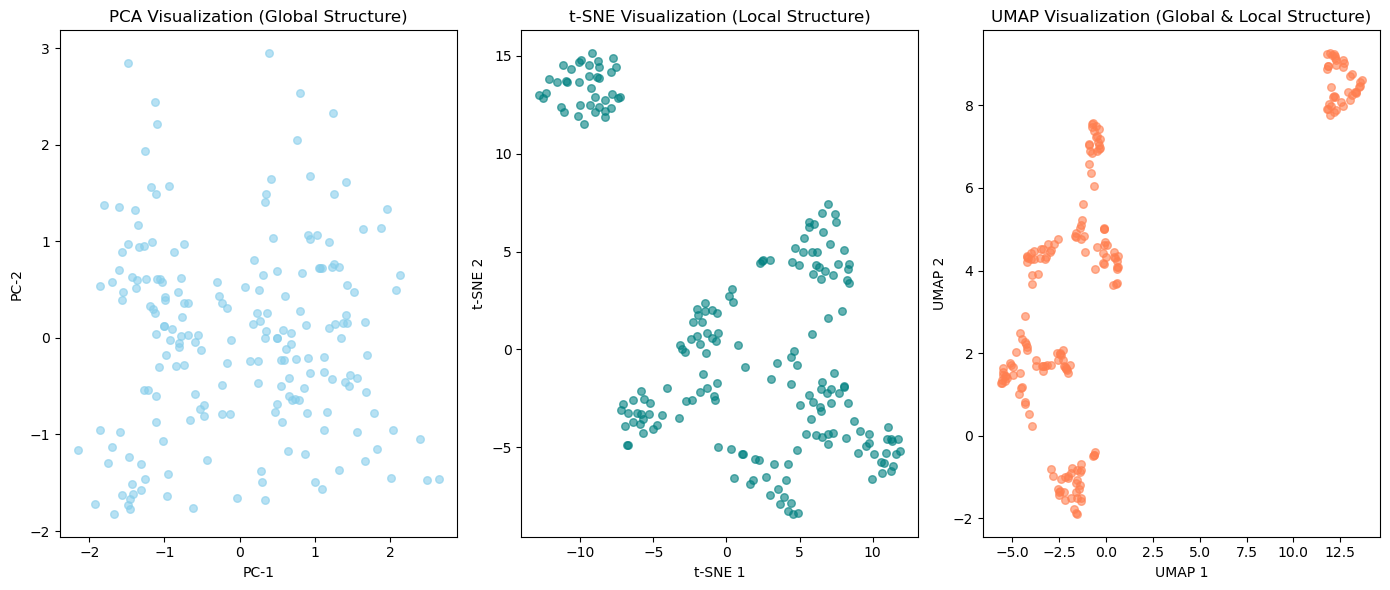

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

axes[0].scatter(X_pca[:,0], X_pca[:,1], alpha=0.6, s=30, c='skyblue')
axes[0].set_title('PCA Visualization (Global Structure)')
axes[0].set_xlabel('PC-1')
axes[0].set_ylabel('PC-2')

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6, s=30, c='teal')
axes[1].set_title('t-SNE Visualization (Local Structure)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

axes[2].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.6, s=30, c='coral')
axes[2].set_title('UMAP Visualization (Global & Local Structure)')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')


plt.tight_layout()
plt.show()

c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


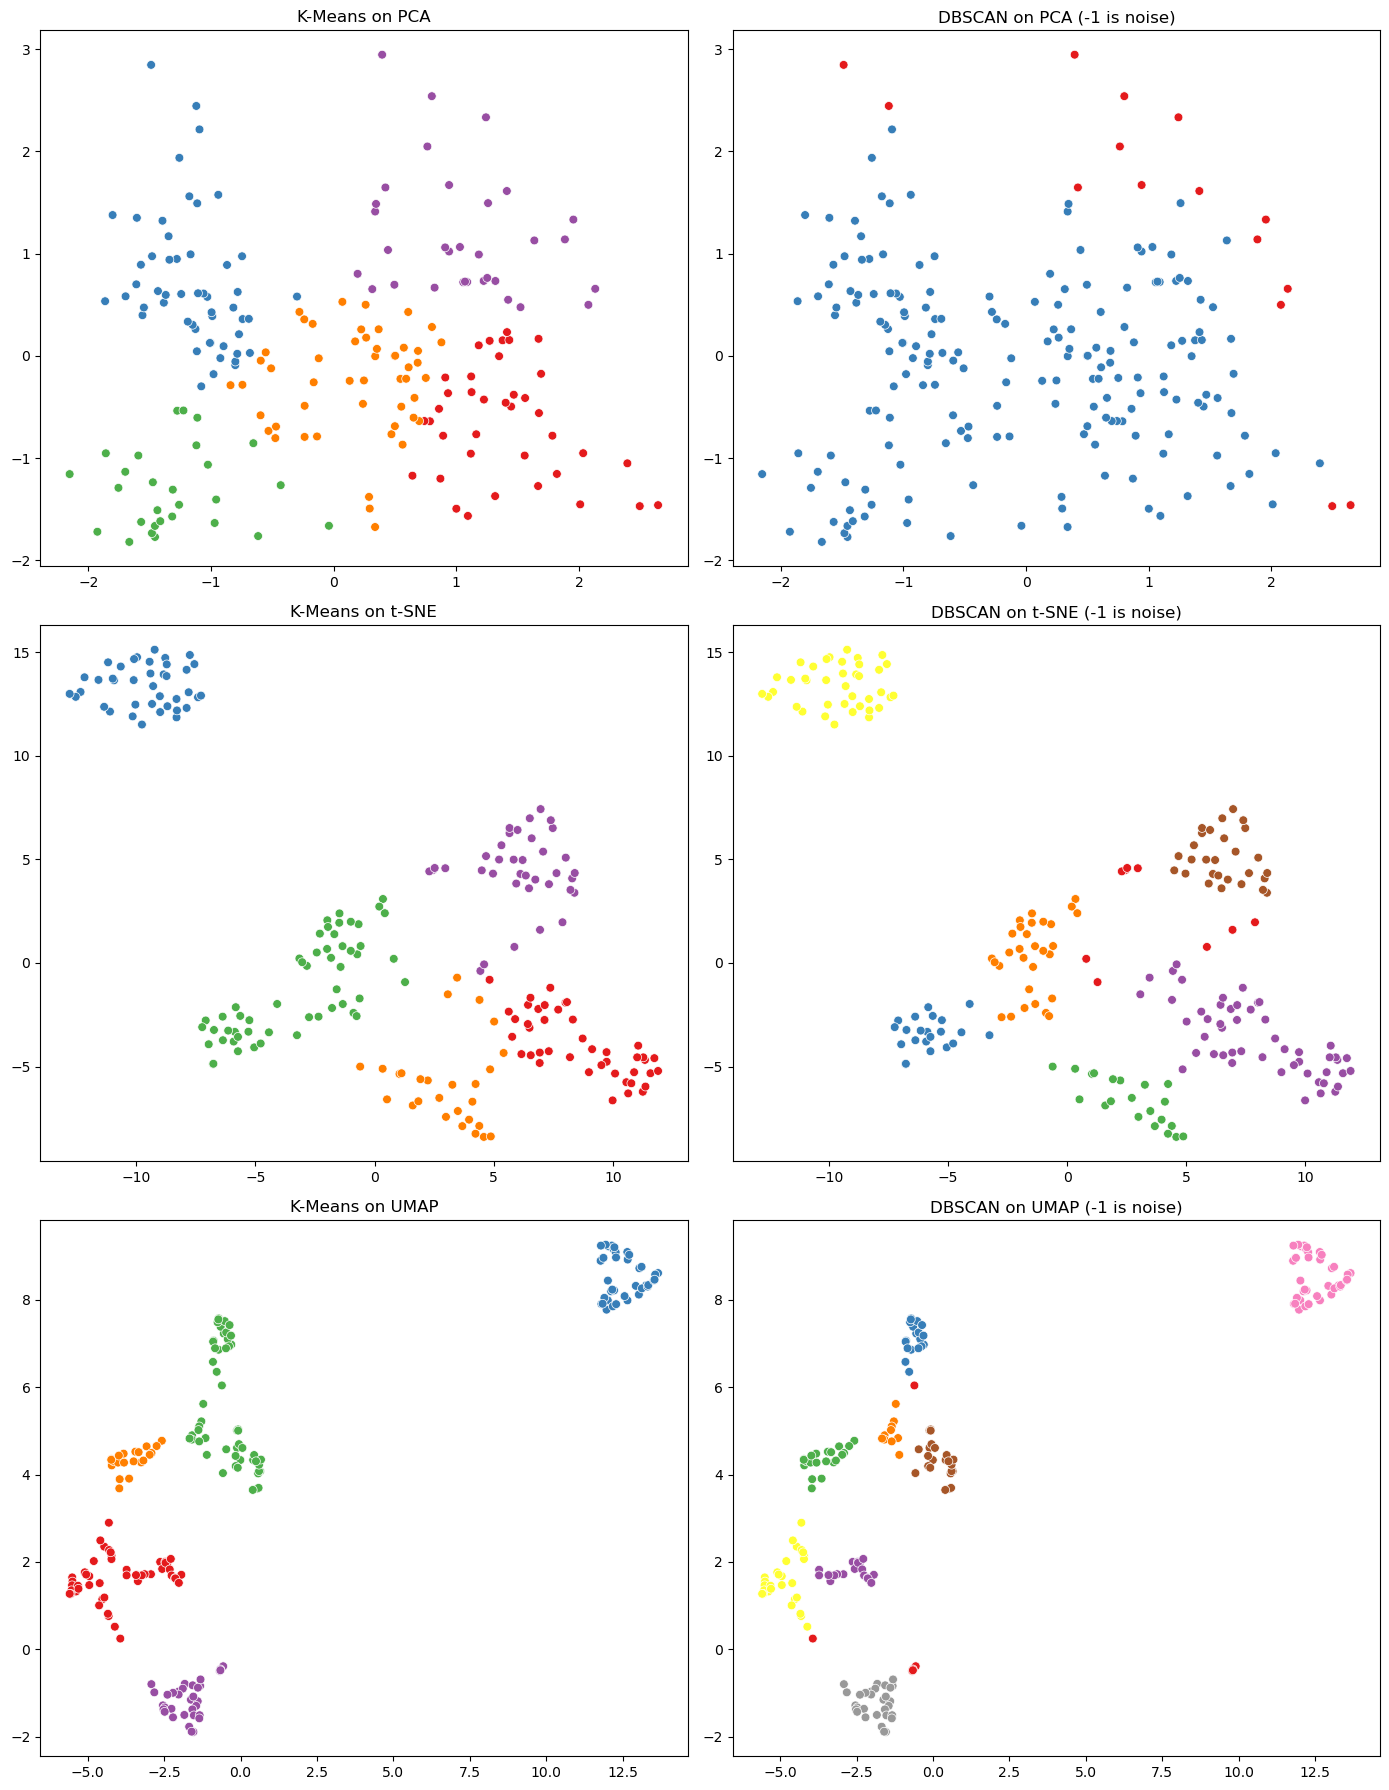

In [18]:
k = 5
# --- PCA Models ---
kmeans_pca = KMeans(n_clusters=k, init='k-means++', random_state=42).fit_predict(X_pca)
dbscan_pca = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_pca)

# --- t-SNE Models ---
kmeans_tsne = KMeans(n_clusters=k, init='k-means++', random_state=42).fit_predict(X_tsne)
dbscan_tsne = DBSCAN(eps=1.5, min_samples=5).fit_predict(X_tsne) # Note: t-SNE scale often requires larger eps for DBSCAN

# --- UMAP Models ---
kmeans_umap = KMeans(n_clusters=k, init='k-means++', random_state=42).fit_predict(X_umap)
dbscan_umap = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_umap)


# --- 4. VISUAL COMPARISON GRID (3 Rows x 2 Columns) ---
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# Row 1: PCA
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_pca, palette='Set1', ax=axes[0, 0], s=40, legend=False)
axes[0, 0].set_title('K-Means on PCA')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_pca, palette='Set1', ax=axes[0, 1], s=40, legend=False)
axes[0, 1].set_title('DBSCAN on PCA (-1 is noise)')

# Row 2: t-SNE
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans_tsne, palette='Set1', ax=axes[1, 0], s=40, legend=False)
axes[1, 0].set_title('K-Means on t-SNE')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=dbscan_tsne, palette='Set1', ax=axes[1, 1], s=40, legend=False)
axes[1, 1].set_title('DBSCAN on t-SNE (-1 is noise)')

# Row 3: UMAP
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=kmeans_umap, palette='Set1', ax=axes[2, 0], s=40, legend=False)
axes[2, 0].set_title('K-Means on UMAP')

sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=dbscan_umap, palette='Set1', ax=axes[2, 1], s=40, legend=False)
axes[2, 1].set_title('DBSCAN on UMAP (-1 is noise)')

plt.tight_layout()
plt.show()

In [22]:
print(kmeans_pca)
print(kmeans_tsne)
print(kmeans_umap)

[2 2 4 2 2 2 0 2 0 2 0 2 0 2 0 2 4 2 0 2 4 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 4 2 0 2 0 2 0 2 4 4 4 4 4 4 4 0 0 4 4 0 4 0 0 2 0 4 0 2 4 0 2 4 0 4 0 0
 0 4 4 4 4 4 0 4 0 4 1 4 4 1 4 4 0 1 4 4 4 1 4 4 4 1 4 4 0 1 4 1 0 4 0 0 0
 1 4 1 1 1 0 4 4 4 1 4 4 1 4 1 4 1 3 1 3 1 4 1 4 1 3 1 4 1 3 1 1 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]
[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 0 2 4 2 4 2 0 2 2 2 0 2 2 0 0 4 0 0 2 0 0 2 0 0 0 2 4 0 2 2 0 0 0 0
 0 2 0 4 2 0 0 4 0 0 2 0 0 2 2 0 0 2 0 0 2 2 0 2 0 2 2 0 0 2 0 2 0 0 0 0 0
 2 3 2 2 2 0 0 0 0 2 3 4 1 2 1 3 1 3 1 3 1 2 1 3 1 3 1 3 1 3 1 2 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]
[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 0 2 0 2 4 2 0 2 2 2 0 2 2 0 0 0 0 0 2 0 0 2 0 0 0 2 0 0 2 2 0 0 0 0
 0 2 0 0 2 0 0 0 0 0 2 0 0 2 2 0 0 2

In [24]:
df_1['Customer_Segment_pca'] = kmeans_pca
df_1['Customer_Segment_tsne'] = kmeans_tsne
df_1['Customer_Segment_umap'] = kmeans_umap
df_1.head()

,Age,Annual Income (k$),Spending Score (1-100),Customer_Segment_pca,Customer_Segment_tsne,Customer_Segment_umap
0,19,15,39,2,4,4
1,21,15,81,2,2,2
2,20,16,6,4,4,4
3,23,16,77,2,2,2
4,31,17,40,2,4,4


In [ ]:
features = ['Customer_Segment_pca', 'Customer_Segment_tsne', 'Customer_Segment_umap']

for feature in features:
    if feature in df_1.columns:
        print(df_1[feature].unique())

[2 4 0 1 3]
[4 2 0 3 1]
[4 2 0 1 3]


In [32]:
features = ['Customer_Segment_pca', 'Customer_Segment_tsne', 'Customer_Segment_umap']

for feature in features:
    if feature in df_1.columns:
       cluster_summary = df_1.groupby(feature)[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
       print("Cluster Averages:\n", cluster_summary)

Cluster Averages:
                       Annual Income (k$)  Spending Score (1-100)
Customer_Segment_pca                                            
0                              41.815789               35.605263
1                              80.576923               74.000000
2                              27.821429               73.535714
3                              89.687500               17.343750
4                              53.680000               44.500000
Cluster Averages:
                        Annual Income (k$)  Spending Score (1-100)
Customer_Segment_tsne                                            
0                               54.232558               49.348837
1                               86.538462               82.128205
2                               43.537037               61.666667
3                               87.000000               18.567568
4                               30.925926               25.851852
Cluster Averages:
                        Ann

In [23]:
print(dbscan_pca)
print(dbscan_tsne)
print(dbscan_umap)

[ 0  0  0  0  0  0  0  0 -1  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1  0 -1  0  0  0  0  0  0  0 -1  0 -1  0 -1  0
 -1  0 -1  0 -1 -1 -1 -1]
[ 1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0
  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  2  0  2  3  1  0  2  3
  3  3  2  3  3  2  2  2  2  2  3  2  2  3  2  2  2  3  2  2  3  3  2  2
  2  2  2  3  2  2  3  2  2  2  2  2  3  2  2  3 -1  2  2  3  2  2 -1  3
  2  3  2  3  3  2  2  3  2  3  2  2  2  2  2  3  2  3  3  3  2  2  2  2
  3  2  2  4  3  4 -1  4 